# Fraud Detection Lab

#### Explore end-to-end ML pipeline for a predictive model to detect Fraud in financial transactions

#### The dataset `fraud.csv` contains the following columns:

1. **step**: Represents a unit of time.
2. **type**: The type of transaction (e.g., "CASH_OUT", "TRANSFER").
3. **amount**: The amount of the transaction.
4. **nameOrig**: The customer identifier for the origin.
5. **oldbalanceOrg**: The balance before the transaction for the origin account.
6. **newbalanceOrig**: The balance after the transaction for the origin account.
7. **nameDest**: The customer identifier for the destination.
8. **oldbalanceDest**: The balance before the transaction for the destination account.
9. **newbalanceDest**: The balance after the transaction for the destination account.
10. **isFraud**: The target variable indicating if the transaction is fraudulent (1 for fraud, 0 for non-fraud).



## 1. Import and inspect data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

%matplotlib inline

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/wsko/Statistics/refs/heads/main/fraud.csv')

In [3]:
print("Dataset Overview:")
display(data.info())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318131 entries, 0 to 318130
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            318131 non-null  int64  
 1   type            318131 non-null  object 
 2   amount          318131 non-null  float64
 3   nameOrig        318131 non-null  object 
 4   oldbalanceOrg   318131 non-null  float64
 5   newbalanceOrig  318131 non-null  float64
 6   nameDest        318131 non-null  object 
 7   oldbalanceDest  318131 non-null  float64
 8   newbalanceDest  318131 non-null  float64
 9   isFraud         318131 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 24.3+ MB


None

In [4]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,345,CASH_OUT,76778.05,C2097594406,99108.00,22329.95,C386232205,0.00,76778.05,0
1,210,CASH_OUT,107058.17,C171085292,123258.57,16200.40,C1839284889,524851.98,631910.15,0
2,37,CASH_IN,43381.03,C856782994,50085.00,93466.03,C2036456346,0.00,0.00,0
3,256,CASH_OUT,67749.17,C717698638,0.00,0.00,C1537680105,405026.26,472775.43,0
4,43,TRANSFER,628687.17,C1189390198,0.00,0.00,C1621505394,763012.87,1391700.05,0


## 2. Feature transformations and preprocessing

In [5]:
data = data.drop(columns=['nameOrig', 'nameDest'])
data.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,345,CASH_OUT,76778.05,99108.00,22329.95,0.00,76778.05,0
1,210,CASH_OUT,107058.17,123258.57,16200.40,524851.98,631910.15,0
2,37,CASH_IN,43381.03,50085.00,93466.03,0.00,0.00,0
3,256,CASH_OUT,67749.17,0.00,0.00,405026.26,472775.43,0
4,43,TRANSFER,628687.17,0.00,0.00,763012.87,1391700.05,0


- Perform one hot encoding for the remaining categorical variables

In [6]:
data = pd.get_dummies(data, drop_first=True)  # Perform one-hot encoding on categorical columns of 'data', dropping the first category to avoid multicollinearity

data.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,345,76778.05,99108.00,22329.95,0.00,76778.05,0,True,False,False,False
1,210,107058.17,123258.57,16200.40,524851.98,631910.15,0,True,False,False,False
2,37,43381.03,50085.00,93466.03,0.00,0.00,0,False,False,False,False
3,256,67749.17,0.00,0.00,405026.26,472775.43,0,True,False,False,False
4,43,628687.17,0.00,0.00,763012.87,1391700.05,0,False,False,False,True


- Create data arrays
- `X` (features) and `y` (label)

In [7]:

X = data.drop(columns=['isFraud']).to_numpy().astype('float')  # Extract features (excluding 'isFraud') as a NumPy array and convert to float type
y = data['isFraud'].to_numpy()  # Extract the target variable 'isFraud' as a NumPy array
feature_names = data.columns[data.columns != 'isFraud']  # Get feature names by excluding the 'isFraud' column


In [8]:
print(feature_names)

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT',
       'type_TRANSFER'],
      dtype='object')


split the data into a train and test set

In [9]:
X_train, X_test, y_train, y_test = train_test_split(  # Split the dataset into training and testing sets
    X, y,  # Features (X) and target labels (y)
    test_size=0.2,  # Use 20% of the data for testing
    stratify=y,  # Ensure the split maintains the same class proportions as in the original data
    random_state=42  # Set random state for reproducibility of the split
)


# Verify the ratio of positive to negative examples in train and test sets
print("Training set fraud ratio:", y_train.mean())
print("Test set fraud ratio:", y_test.mean())

Training set fraud ratio: 0.0012337723572124603
Test set fraud ratio: 0.001225894667358197


## 3. Train and Evaluate a Random Forest Classifier Model


In [10]:
rf = RandomForestClassifier(max_depth = 9, n_estimators=60)  # Initialize a Random Forest classifier
rf.fit(X_train, y_train)  # Train the Random Forest model using the training data

,n_estimators,60
,criterion,'gini'
,max_depth,9
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred = rf.predict(X_test)  # Predict the target labels for the test data using the trained Logistic Regression model
 # Compute precision, recall, and accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Display the results
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")

Precision: 1.0000
Recall: 0.6538
Accuracy: 0.9996


- model interpretation

In [12]:
pd.DataFrame({"feature":feature_names, "importance":rf.feature_importances_})

,feature,importance
0,step,0.071496
1,amount,0.129724
2,oldbalanceOrg,0.303179
3,newbalanceOrig,0.036984
4,oldbalanceDest,0.072262
5,newbalanceDest,0.288595
6,type_CASH_OUT,0.047512
7,type_DEBIT,0.000013
8,type_PAYMENT,0.000536
9,type_TRANSFER,0.049699


- Plot and inspect the ROC Curve
- How good is your model?
- What is the AUC?

In [13]:
from sklearn.metrics import roc_curve, roc_auc_score  # Import ROC curve and AUC score metrics
import matplotlib.pyplot as plt  # Import Matplotlib for plotting

def plot_roc_curve(model, y_true):  # Define a function to plot ROC curve for a given model and true labels
    y_proba = model.predict_proba(X_test)[:, 1]  # Get the predicted probabilities for the positive class (1)

    # Compute the ROC curve (FPR: False Positive Rate, TPR: True Positive Rate, thresholds: Classification thresholds)
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    auc_score = roc_auc_score(y_true, y_proba)  # Calculate the AUC (Area Under the Curve) score for further evaluation

    # Plot the ROC curve
    plt.figure(figsize=(8, 6))  # Set up the figure size
    plt.plot(fpr, tpr, label=f"(AUC = {auc_score:.2f})")  # Plot True Positive Rate against False Positive Rate
    plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")  # Plot a diagonal reference line for random predictions
    plt.xlabel("False Positive Rate")  # Label the x-axis
    plt.ylabel("True Positive Rate")  # Label the y-axis
    plt.title("ROC Curve")  # Add a title to the plot
    plt.legend()  # Display the legend with AUC and reference line
    plt.show()  # Render the ROC curve plot

    return auc_score  # Return the AUC score for further analysis



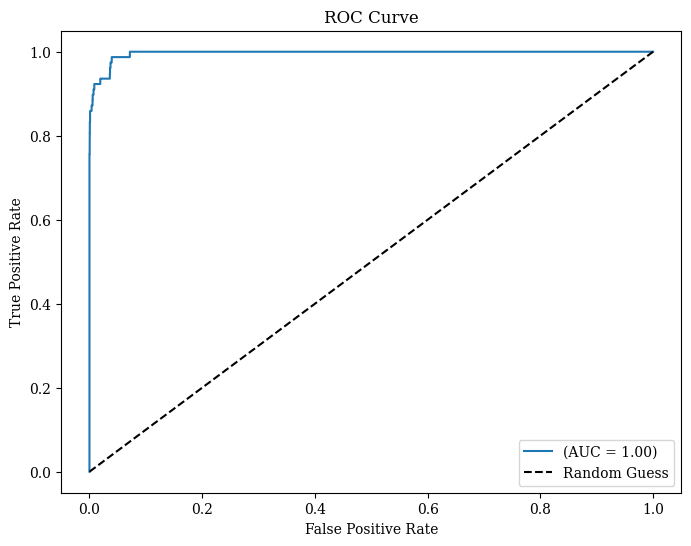

AUC Score: 0.9964563988781521


In [14]:

auc = plot_roc_curve(rf, y_test)
print("AUC Score:", auc)

## 4. Serve Predictions

In [15]:
rf.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0])

In [16]:
rf.predict_proba(X_test)

array([[9.99966019e-01, 3.39812822e-05],
       [9.99966019e-01, 3.39812822e-05],
       [9.99914654e-01, 8.53456208e-05],
       ...,
       [9.99189149e-01, 8.10851409e-04],
       [9.99330840e-01, 6.69160482e-04],
       [9.99985667e-01, 1.43329821e-05]])